In [1]:
%pip install diffusers transformers accelerate torch

In [2]:
import torch
from diffusers import StableDiffusionPipeline
from diffusers import FluxPipeline

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
from huggingface_hub import login

token = ""
if len(token) > 0:
    login(token=token)

In [4]:
pipe = None
# from diffusers import StableDiffusionInpaintPipeline
# from PIL import Image
from diffusers import StableDiffusionXLPipeline
if False:
  # realistic person
  model_id = "black-forest-labs/FLUX.1-schnell"
  pipe = FluxPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16
  )
elif False:
  pipe = FluxPipeline.from_pretrained("black-forest-labs/FLUX.1-schnell", torch_dtype=torch.bfloat16)
  # pipe.enable_model_cpu_offload()
elif True:
  model_id = "stablediffusionapi/juggernaut-xl-v9"
  pipe = StableDiffusionXLPipeline.from_pretrained(model_id, torch_dtype=torch.float16)

else:
  model_id = "runwayml/stable-diffusion-v1-5"
  pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/676 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [5]:
if False:
  pipe.enable_sequential_cpu_offload()

# 3. Optional: Add attention slicing for extra safety
  pipe.enable_attention_slicing()
else:
  pipe = pipe.to("cuda")

In [6]:
def disabled_safety_checker(images, **kwargs):
    return images, [False] * len(images)

pipe.safety_checker = disabled_safety_checker

In [11]:
prompt = """
dragon in game of thrones
"""

In [12]:
# from PIL import Image
# original_image = Image.open("./sample.jpg")
image = pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

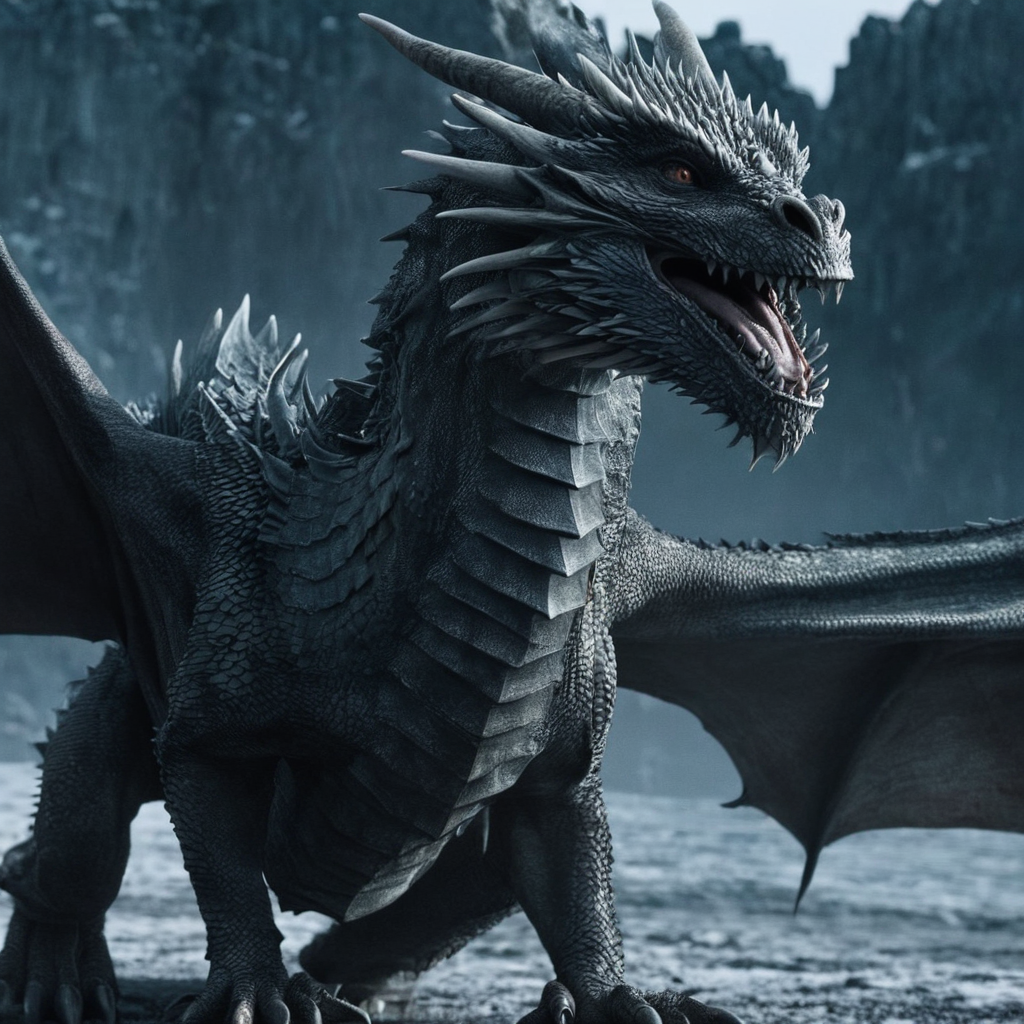

In [13]:
image

In [ ]:
image.save("my_generated_image.png")